In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

input_path = "../dataset/quantity_weekly_decor_outlier_fixed.csv"

df = pd.read_csv(input_path)
weeks = df.columns[1:]
dates = pd.date_range(start='2010-12-01', periods=len(weeks), freq='W')
p = 6

def analyze_series_stl(ts, period=6):
    res = {}
    
    ts_diff = ts.diff().dropna()
    adf_diff = adfuller(ts_diff)
    res['ADF_p_value'] = round(adf_diff[1], 4)
    res['Is_Stationarity'] = "Yes" if adf_diff[1] < 0.05 else "No"
    
    stl = STL(ts, period=period, robust=True)
    decomp = stl.fit()
    
    resid = decomp.resid
    trend = decomp.trend
    seasonal = decomp.seasonal
    var_resid = np.var(resid)
    
    var_trend_resid = np.var(trend + resid)
    if var_trend_resid == 0:
        trend_strength = 0
    else:
        trend_strength = max(0, 1 - var_resid / var_trend_resid)
    
    res['Trend_Strength'] = round(trend_strength, 4)
    res['Have_Trend'] = "Yes" if trend_strength > 0.6 else "No"
    
    var_seasonal_resid = np.var(seasonal + resid)
    if var_seasonal_resid == 0:
        seasonal_strength = 0
    else:
        seasonal_strength = max(0, 1 - var_resid / var_seasonal_resid)
        
    res['Seasonal_Strength'] = round(seasonal_strength, 4)
    res['Have_Seasonality'] = "Yes" if seasonal_strength > 0.6 else "No"
    
    return res

final_results = []

for index, row in df.iterrows():
    stock_code = str(row['StockCode'])
    series_data = pd.to_numeric(row[1:], errors='coerce').values.astype(float)
    series_data = np.nan_to_num(series_data, nan=1e-6)
    series_data[series_data <= 0] = 1e-6
    ts = pd.Series(series_data, index=dates)
    
    try:
        stats = analyze_series_stl(ts, period=p)
        stats['StockCode'] = stock_code
        final_results.append(stats)
    except Exception as e:
        print(f"{stock_code}: {e}")

df_results = pd.DataFrame(final_results)
cols = ['StockCode', 'Is_Stationarity', 'ADF_p_value', 'Have_Trend', 'Trend_Strength', 'Have_Seasonality', 'Seasonal_Strength']
df_results = df_results[cols]

print(df_results.to_string(index=False))

StockCode Is_Stationarity  ADF_p_value Have_Trend  Trend_Strength Have_Seasonality  Seasonal_Strength
    22469             Yes       0.0186         No          0.5121               No             0.1086
    22961             Yes       0.0008         No          0.4103               No             0.1059
    21181             Yes       0.0000         No          0.5821               No             0.0000
    21137             Yes       0.0000        Yes          0.8384               No             0.2730
    84978             Yes       0.0004        Yes          0.9407              Yes             0.6526
    21326             Yes       0.0000         No          0.2488               No             0.0000
    22969             Yes       0.0008        Yes          0.6090               No             0.1528
    79321             Yes       0.0002         No          0.5330               No             0.0000
    84945              No       0.0872         No          0.4692               No

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

trend_stocks = df_results[df_results['Have_Trend'] == 'Yes']['StockCode'].tolist()

ets_results = []

print(f"Số mã sản phẩm: {len(trend_stocks)}/{df.shape[0]}")

for stock in trend_stocks:
    series_data = pd.to_numeric(df[df['StockCode'].astype(str) == stock].iloc[0, 1:], errors='coerce').values
    series_data = np.nan_to_num(series_data, nan=1e-6)
    
    test_size = 4
    train_data = series_data[:-test_size]
    test_data = series_data[-test_size:]
    
    try:
        model = ExponentialSmoothing(train_data, trend='add', seasonal=None, initialization_method="estimated")
        model_fit = model.fit()
        
        forecast = model_fit.forecast(steps=test_size)
        
        mae = mean_absolute_error(test_data, forecast)
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        mape = mean_absolute_percentage_error(test_data, forecast)
        
        ets_results.append({
            'StockCode': stock,
            'Model': 'ETS(A,A,N)',
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'MAPE (%)': round(mape, 2),
            'Forecast': forecast,
            'Actual': test_data,
            'Train_Data': train_data
        })
    except Exception as e:
        print(f"{stock}: {e}")

df_ets_compare = pd.DataFrame(ets_results)
print("\nKết quả:")
print(df_ets_compare[['StockCode', 'Model', 'MAE', 'RMSE', 'MAPE (%)']].head(50))

Số mã sản phẩm: 20/41

Kết quả:
   StockCode       Model     MAE    RMSE  MAPE (%)
0      21137  ETS(A,A,N)  1.0803  1.4742     24.01
1      84978  ETS(A,A,N)  0.1424  0.1803      2.79
2      22969  ETS(A,A,N)  0.1272  0.1503      2.51
3      21175  ETS(A,A,N)  0.1129  0.1467      2.47
4      82482  ETS(A,A,N)  0.0824  0.1103      1.65
5     84970S  ETS(A,A,N)  0.4728  0.5348      9.67
6      85152  ETS(A,A,N)  1.0209  1.0731     19.42
7      21733  ETS(A,A,N)  0.7840  0.8973     15.98
8      23298  ETS(A,A,N)  2.7620  3.1905     66.06
9     75049L  ETS(A,A,N)  1.2499  1.2773     27.19
10     22666  ETS(A,A,N)  0.1888  0.2097      4.05
11     22727  ETS(A,A,N)  0.7352  0.7795     14.62
12     22090  ETS(A,A,N)  0.1269  0.1720      2.88
13     72741  ETS(A,A,N)  1.0402  1.0750     24.88
14     40016  ETS(A,A,N)  1.4407  1.4415     42.85
15     84836  ETS(A,A,N)  0.3064  0.3526      7.58
16     21231  ETS(A,A,N)  0.2175  0.2466      4.71
17    84970L  ETS(A,A,N)  0.1016  0.1131      2.33

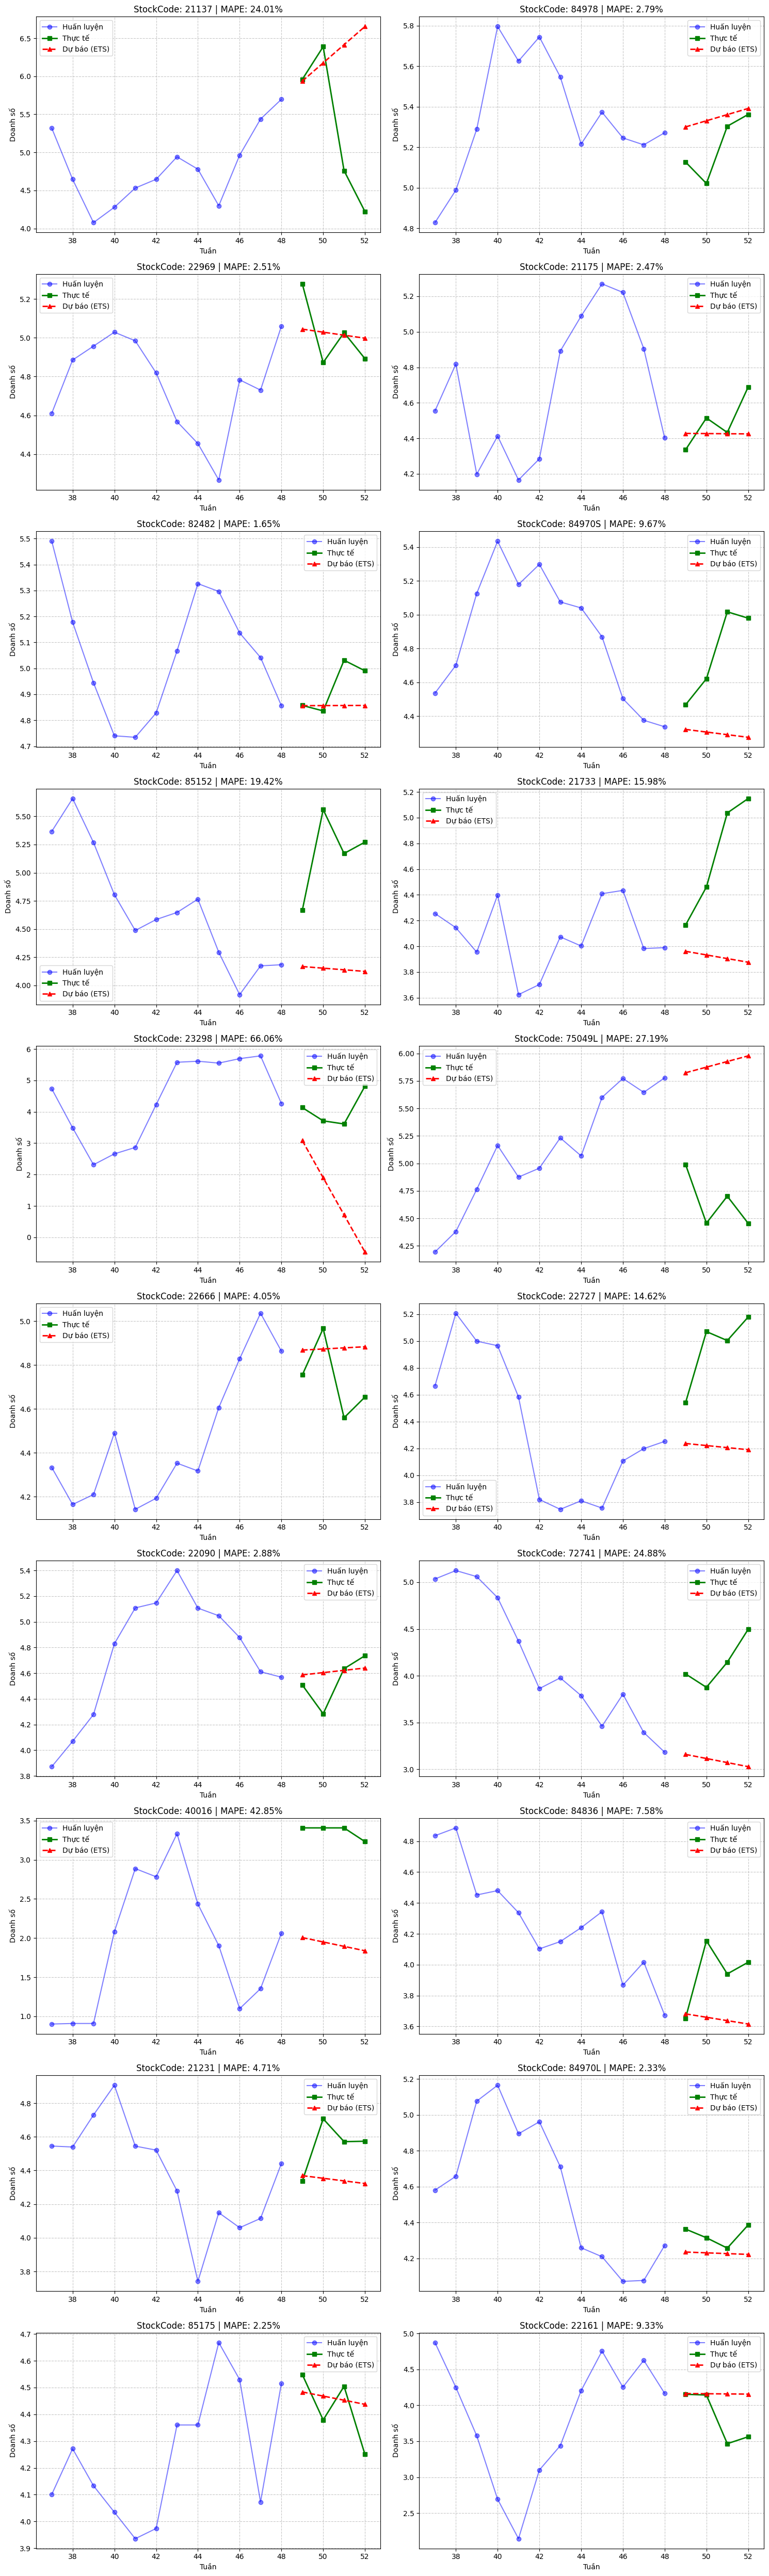

In [31]:
import matplotlib.pyplot as plt

def plot_ets_forecast(df_results, num_stocks=6):
    num_stocks = min(num_stocks, len(df_results))
    rows = (num_stocks + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i in range(num_stocks):
        res = df_results.iloc[i]
        stock = res['StockCode']
        train_data = res['Train_Data']
        test_data = res['Actual']
        forecast = res['Forecast']
        
        ax = axes[i]
        
        lookback = 12
        train_idx = np.arange(len(train_data) - lookback, len(train_data))
        ax.plot(train_idx, train_data[-lookback:], label='Huấn luyện', color='blue', marker='o', alpha=0.5)
        
        test_idx = np.arange(len(train_data), len(train_data) + len(test_data))
        ax.plot(test_idx, test_data, label='Thực tế', color='green', marker='s', linewidth=2)
        ax.plot(test_idx, forecast, label='Dự báo (ETS)', color='red', linestyle='--', marker='^', linewidth=2)
        
        ax.set_title(f"StockCode: {stock} | MAPE: {res['MAPE (%)']}%")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlabel("Tuần")
        ax.set_ylabel("Doanh số")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_ets_forecast(df_ets_compare, num_stocks=50)